In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
import time
from datetime import timedelta

Nr = 16 # Nombre d'éléments

# Chargement des Data
input_signals = np.load("../Data/X_mvdr_400k.npy")  # Shape attendue: (100000, 3)
output_signals = np.load("../Data/Y_mvdr_400k.npy") # Shape attendue: (100000, 32)

# 2. NORMALISATION DES POIDS (Y)
# On calcule la norme de chaque ligne (chaque vecteur de 32 éléments)
# La norme d'un vecteur complexe w est sqrt(sum(Re^2 + Im^2))
normes = np.linalg.norm(output_signals, axis=1, keepdims=True)
output_signals = output_signals / normes

# 3. NORMALISATION DES ANGLES (X)
input_x = torch.from_numpy(input_signals).float() / 60.0
output_x = torch.from_numpy(output_signals).float()

print(f"Poids normalisés. Nouvelle norme moyenne : {torch.norm(output_x[0]):.2f}")
print(input_x.shape)
print(output_x.shape)

Poids normalisés. Nouvelle norme moyenne : 1.00
torch.Size([400000, 3])
torch.Size([400000, 32])


In [2]:
# des couches de taille multiple de 32       #<---------------------------------------------
class MVDR_FFNN(nn.Module):
    def __init__(self):
        super(MVDR_FFNN, self).__init__()
        self.layer1 = nn.Linear(3, 256)
        self.layer2 = nn.Linear(256, 512)
        self.layer3 = nn.Linear(512, 512)
        self.layer4 = nn.Linear(512, 1024)
        self.layer5 = nn.Linear(1024, 32) # Dernière couche 
        
    def forward(self, x):
        # 1. Les L-1 premières couches cachées leaky_relu  x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer2(x), 0.1)
        x = F.leaky_relu(self.layer3(x), 0.1)
        x = F.leaky_relu(self.layer4(x), 0.1)
               
        x = self.layer5(x)        
        return x

class RMSELoss(nn.Module):      #<---------------------------------------------
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_hat, y):
        loss = torch.sqrt(self.mse(y_hat, y) + self.eps)
        return loss

# =================================================================================================================

# =================================================================================================================

# Device cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Model
model = MVDR_FFNN().to(device)
print(model)

# 1. Création du Dataset complet
dataset = TensorDataset(input_x, output_x)

# Division 70% Train, 15% Val, 15% Test
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
# 2. Division réelle
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
# 3. Création des DataLoaders
# Train : Shuffle=True (pour l'apprentissage)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, pin_memory=True)
# Validation : Shuffle=False (pour le suivi du scheduler pendant l'entraînement)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
# Test : Shuffle=False (pour l'évaluation finale "propre")
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)#<---------------------------------------------

# Utilisation de la MSE (Mean Squared Error) pour comparer les poids
criterion = RMSELoss()

# AdamW avec un Learning Rate standard
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)        #<---------------------------------------------

# =================================================================================================================

# =================================================================================================================

# Optionnel : Un scheduler pour réduire le LR si la perte stagne
# (Aide à obtenir des "nuls" plus profonds à la fin de l'entraînement)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Initialisation
train_losses = []
test_losses = []
epochs = 300  #<---------------------------------------------

# Configuration du Scheduler Cosine
# Il va descendre de façon fluide sans les "marches d'escalier"
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

start_time = time.time()  # On lance le chrono global
print(f" Début de l'entraînement à : {time.strftime('%H:%M:%S')}")

for epoch in range(epochs):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train()
    running_train_loss = 0.0
    # On garde tqdm pour la barre de progression par époque
    loop = tqdm(train_loader, desc=f"Époque [{epoch+1}/{epochs}]", leave=False)
    
    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)        
        loss = criterion(outputs, targets)        
        loss.backward()       
        optimizer.step()       
        
        running_train_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.2e}")

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- PHASE DE TEST (VALIDATION) ---
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader: 
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item()
    
    epoch_test_loss = running_test_loss / len(val_loader)
    test_losses.append(epoch_test_loss)
    
    # Mise à jour du scheduler Cosine (automatique à chaque époque)
    scheduler.step()

    # Récupération du LR actuel pour le suivi
    current_lr = optimizer.param_groups[0]['lr']

    # AFFICHAGE (Indenté à l'intérieur de la boucle pour voir l'évolution)
    # On affiche toutes les époques (ou tu peux mettre un if epoch % 10 == 0:)
    if (epoch + 1) % 10 == 0:
        print(f"Époque [{epoch+1}/{epochs}] | Train: {epoch_train_loss:.6f} | Test: {epoch_test_loss:.6f} | LR: {current_lr:.2e}")

# Calcul du temps total de l'entrainement.
end_time = time.time()
total_duration_seconds = end_time - start_time

# Conversion magique en Heures:Minutes:Secondes
total_time = str(timedelta(seconds=int(total_duration_seconds)))

print("-" * 50)
print(f"✅ ENTRAÎNEMENT TERMINÉ")
print(f"⏱️ TEMPS TOTAL : {total_time} (HH:MM:SS)")
print("-" * 50)
        

MVDR_FFNN(
  (layer1): Linear(in_features=3, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=512, bias=True)
  (layer3): Linear(in_features=512, out_features=512, bias=True)
  (layer4): Linear(in_features=512, out_features=1024, bias=True)
  (layer5): Linear(in_features=1024, out_features=32, bias=True)
)
 Début de l'entraînement à : 15:50:33


Époque [10/300] | Train: 0.021013 | Test: 0.019072 | LR: 9.97e-04


Époque [20/300] | Train: 0.017610 | Test: 0.018816 | LR: 9.89e-04


Époque [30/300] | Train: 0.015338 | Test: 0.016382 | LR: 9.76e-04


Époque [40/300] | Train: 0.013668 | Test: 0.013631 | LR: 9.57e-04


...

Époque [260/300] | Train: 0.006754 | Test: 0.006936 | LR: 4.33e-05


Époque [270/300] | Train: 0.006710 | Test: 0.006891 | LR: 2.46e-05


Époque [280/300] | Train: 0.006675 | Test: 0.006867 | LR: 1.10e-05


Époque [290/300] | Train: 0.006653 | Test: 0.006852 | LR: 2.84e-06


Époque [300/300] | Train: 0.006643 | Test: 0.006846 | LR: 1.00e-07
--------------------------------------------------
✅ ENTRAÎNEMENT TERMINÉ
⏱️ TEMPS TOTAL : 0:17:13 (HH:MM:SS)
--------------------------------------------------


In [3]:
# =================================================================================================================
# PHASE DE TEST FINAL (RÉGRESSION MVDR)
# =================================================================================================================
model.eval()
total_rmse = 0.0
total_mse = 0.0
test_samples_count = 0

# Listes pour stocker quelques résultats pour analyse visuelle
all_preds = []
all_targets = []

print(f"\n🚀 Lancement du test final sur l'ensemble de TEST ({len(test_dataset)} échantillons)...")

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Inférence (Prédiction des poids)
        outputs = model(inputs)
        
        # Calcul de l'erreur (RMSE via ton critère personnalisé)
        loss = criterion(outputs, targets)
        
        # Accumulation des statistiques
        total_rmse += loss.item() * inputs.size(0)
        total_mse += torch.mean((outputs - targets)**2).item() * inputs.size(0)
        test_samples_count += inputs.size(0)
        
        # Sauvegarde d'un batch pour la visualisation
        if len(all_preds) < 1: 
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

# Calcul des moyennes finales
final_rmse = total_rmse / test_samples_count
final_mse = total_mse / test_samples_count

print("-" * 60)
print(f"📊 RÉSULTATS DU TEST FINAL (SUR PC - FLOAT32)")
print(f"🔹 RMSE Moyenne : {final_rmse:.8f}")
print(f"🔹 MSE Moyenne  : {final_mse:.8e}")
# Calcul d'un score de corrélation ou de proximité
score_proximite = 100 * (1 - final_rmse)
print(f"🔹 Score de fidélité estimé : {max(0, score_proximite):.2f}%")
print("-" * 60)



🚀 Lancement du test final sur l'ensemble de TEST (60000 échantillons)...
------------------------------------------------------------
📊 RÉSULTATS DU TEST FINAL (SUR PC - FLOAT32)
🔹 RMSE Moyenne : 0.00685342
🔹 MSE Moyenne  : 4.69624938e-05
🔹 Score de fidélité estimé : 99.31%
------------------------------------------------------------


✅ Graphique sauvegardé : ../models_FFNN/MVDR_FFNN20260409_1608_loss_comparison.png
💾 MODÈLE SAUVEGARDÉ : ../models_FFNN/MVDR_FFNN20260409_1608_model.pth


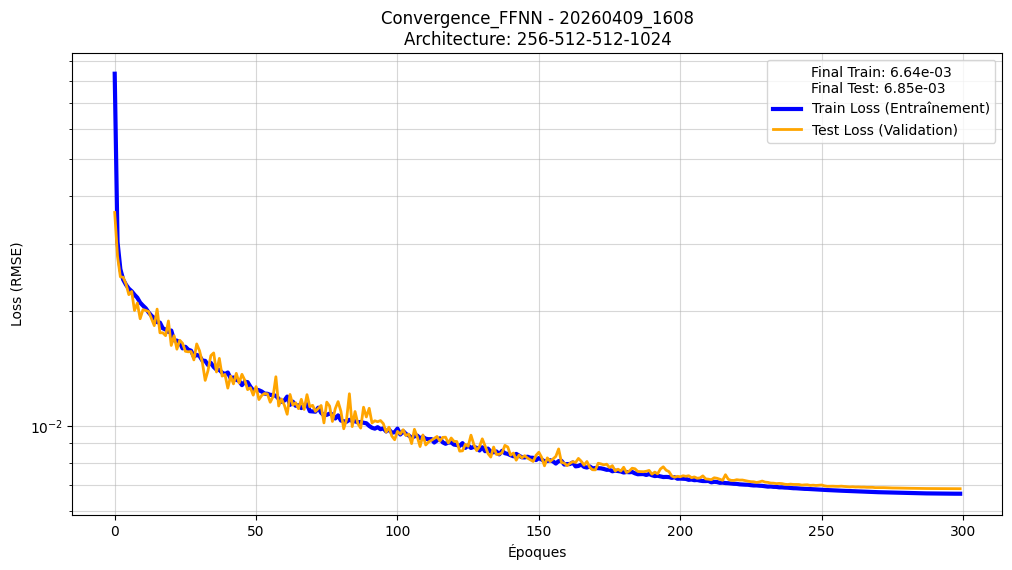

✅ Graphique sauvegardé : ../models_FFNN/MVDR_FFNN20260409_1608_loss_comparison.png


In [4]:
import os
from datetime import datetime
import matplotlib.pyplot as plt

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
base_filename = f"MVDR_FFNN{timestamp}"

# --- AJOUT POUR SAUVEGARDER LES POIDS DU MODÈLE ---
model_filename = f"{base_filename}_model.pth"
folder_name = "../models_FFNN"
model_path = os.path.join(folder_name, model_filename)
plot_path = os.path.join(folder_name, f"{base_filename}_loss_comparison.png")

# Sauvegarde des poids (state_dict)
torch.save(model.state_dict(), model_path)

print(f"✅ Graphique sauvegardé : {plot_path}")
print(f"💾 MODÈLE SAUVEGARDÉ : {model_path}") # <--- Très important !

# 1. RÉACTIVER L'AFFICHAGE (Annule le mode "Agg")
%matplotlib inline 

# 2. REDÉFINIR LES CHEMINS (Pour éviter le NameError)

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 3. TRACÉ DE LA COURBE
plt.figure(figsize=(12, 6))

plt.plot(train_losses, label='Train Loss (Entraînement)', color='blue', linewidth=3)
plt.plot(test_losses, label='Test Loss (Validation)', color='orange', linewidth=2)

plt.yscale('log') 
plt.title(f"Convergence_FFNN - {timestamp}\nArchitecture: 256-512-512-1024", fontsize=12)
plt.xlabel("Époques")
plt.ylabel("Loss (RMSE)")
plt.grid(True, which="both", alpha=0.5)

# Légende avec les scores finaux
last_train = train_losses[-1]
last_test = test_losses[-1]
plt.legend(title=f"Final Train: {last_train:.2e}\nFinal Test: {last_test:.2e}", loc='upper right')

# 4. SAUVEGARDE ET AFFICHAGE
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show() # Maintenant ça va s'afficher car on a mis %matplotlib inline

print(f"✅ Graphique sauvegardé : {plot_path}")